In [1]:
import numpy as np
import pandas as pd

from src.data_preparation.signal_adjustment import get_signal_baseline

In [2]:
x_label = "Time, ns"
y_label = "Bit ADC"
signal_count = 23479
adc_inversion_term = 2 ** 14

In [3]:
dataset = pd.read_csv('../data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [4]:
dataset_baseline = get_signal_baseline(dataset, adc_inversion_term)
df_raw = (adc_inversion_term - dataset - dataset_baseline)
assert df_raw.min().min() == 0
assert df_raw.shape[0] == signal_count

In [5]:
threshold = 30
mask_1 = df_raw.iloc[:, 40:70].max(axis=1) > threshold
mask_2 = df_raw.iloc[:, 120:140].max(axis=1) > threshold
highlight_indices = df_raw[mask_1 | mask_2].index.tolist()
highlight_indices

[3321, 11849]

Text(0, 0.5, 'Bit ADC')

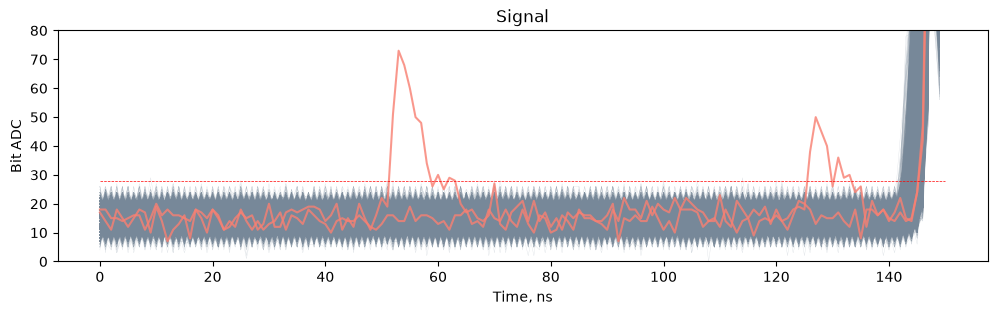

In [6]:
ax = df_raw.iloc[:, :150].T.plot(title='Signal', legend=None, figsize=(12, 3), alpha=0.25, linewidth=0.25,
                                 color='lightslategrey')
for idx in highlight_indices:
    ax.plot(df_raw.columns[:150], df_raw.iloc[idx, :150],
            color='salmon', linewidth=1.5, alpha=0.8)
ax.hlines(y=[28], xmin=0, xmax=150, color='r', linestyle='--', linewidth=0.5)
ax.set_ylim(0, 80)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

In [7]:
df = pd.DataFrame({'data_array': df_raw.apply(lambda row: np.array(row.values), axis=1)})

In [8]:
df.to_parquet("../data/Run200_Wave_0_1_preprocessed.parquet")